---

<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">Redes Neurais Artificiais, Deep Learning e Algoritmos Genéticos</h1>

<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
</div>

---

## Organização deste notebook

Este material constrói, do zero, um modelo de **regressão linear treinado por gradiente descendente**  a base de todo algoritmo de aprendizado de máquina. O fluxo está dividido em **5 partes**:

| Parte | Conteúdo |
|-------|----------|
| **1** | Geração do dataset sintético e visualização |
| **2** | Inicialização dos parâmetros do modelo |
| **3** | Base matemática: forward, loss e backward |
| **4** | Execução do loop de treinamento |
| **5** | Avaliação visual e métrica do resultado |

> **Por que regressão linear?**  
> É o modelo mais simples possível, mas já contém todos os ingredientes de redes neurais: pesos, função de custo, gradiente e atualização iterativa de parâmetros.

In [ ]:
# Instalação das dependências
# %pip install numpy matplotlib --quiet

## Bibliotecas utilizadas

| Biblioteca | Uso neste notebook |
|---|---|
| `numpy` | Operações vetorizadas: produto, soma, média  executadas de forma eficiente sobre arrays |
| `matplotlib` | Geração de gráficos para visualizar os dados e a curva de aprendizado |

> As operações matemáticas do gradiente descendente (somatórios, médias) são implementadas com vetores NumPy, evitando laços Python explícitos e aproveitando operações de álgebra linear otimizadas.

In [1]:
# numpy para cálculos matemáticos
# matplotlib para visualização de dados

import numpy as np
import matplotlib.pyplot as plt

# Parte 1: Preparação do problema e geração do dataset

O objetivo é criar dados que sigam uma relação linear entre entrada $x$ e saída $y$, com um ruído gaussiano $\varepsilon$ adicionado para simular variação real:

$$
y_i = w_{\text{true}} \cdot x_i + b_{\text{true}} + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0, \sigma^2)
$$

onde:
- $w_{\text{true}} = 2.0$ e $b_{\text{true}} = 3.0$ são os parâmetros **reais** que o modelo deverá recuperar após o treinamento;
- $\varepsilon_i$ é o ruído com desvio padrão $\sigma$  quanto maior $\sigma$, mais dispersa a nuvem de pontos.

**Passos desta parte:**
1. Definir `create_dataset`: gera $y$ a partir de $x$, com ruído controlado.
2. Criar os vetores de entrada (`x`) e saída alvo (`y`).
3. Plotar os dados para confirmar o padrão linear antes do treinamento.

---

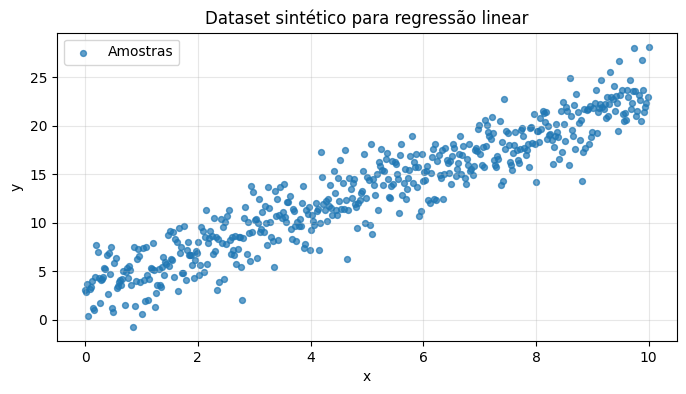

In [2]:
# Gera dados de regressão linear com ruído controlado

def create_dataset(x, w, b=3.0, noise_std=0.3):
    noise = np.random.normal(loc=0.0, scale=noise_std, size=x.shape[0])
    return w * x + b + noise

x = np.linspace(0, 10, 500)
y = create_dataset(x, w=2.0, b=3.0, noise_std=2)

plt.figure(figsize=(8, 4))
plt.scatter(x, y, s=18, alpha=0.7, label="Amostras")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Dataset sintético para regressão linear")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Parte 2: Inicialização dos parâmetros

Todo modelo de aprendizado de máquina começa com uma estimativa inicial para seus parâmetros. Aqui temos dois:

| Parâmetro | Símbolo | Valor inicial | Papel no modelo |
|-----------|---------|---------------|-----------------|
| Peso | $w$ | aleatório $\sim \mathcal{N}(0,1)$ | controla a inclinação da reta |
| Bias | $b$ | $0$ | controla o deslocamento vertical |

**Por que inicializar $w$ aleatoriamente?**  
Se todos os parâmetros começassem iguais a zero, os gradientes seriam idênticos e os parâmetros nunca se diferenciariam. A inicialização aleatória quebra essa simetria e permite que o gradiente descendente explore diferentes direções.

**Objetivo:** observar como $w$ e $b$ evoluem a partir de valores arbitrários até convergir para os valores reais ($w \approx 2$, $b \approx 3$).

In [3]:
# inicializar os pesos e bias

w = float(np.random.randn())
b = 0.0

print(f"Pesos iniciais: w = {w:.4f}, b = {b:.4f}")

Pesos iniciais: w = 1.1361, b = 0.0000


## Parte 3: Construção da base matemática do modelo

O treinamento de um modelo supervisionado segue sempre o mesmo ciclo de três etapas, repetido por várias **épocas**:

```
Para cada época:
  1. Forward  →  calcula a predição ŷ com os parâmetros atuais
  2. Loss     →  mede o quão errada está a predição
  3. Backward →  calcula em qual direção e quanto ajustar w e b
```

As subseções a seguir apresentam as equações de cada etapa e depois a implementação correspondente em Python.

### Equações do modelo: Forward, Loss e Backward

---

#### 3.1 Forward Propagation (predição)

Dado o vetor de entrada $\mathbf{x} \in \mathbb{R}^N$, a predição para cada amostra $i$ é:

$$
\hat{y}_i = w \, x_i + b
$$

Em notação vetorial (para todas as $N$ amostras de uma vez):

$$
\hat{\mathbf{y}} = w\mathbf{x} + b
$$

Isso é uma **transformação afim**  a operação mais básica de uma rede neural.

---

#### 3.2 Função de Custo  MSE (Mean Squared Error)

Precisamos de um número que resuma o erro total do modelo. Usamos o **erro quadrático médio**:

$$
\mathcal{L}(w,b) = \frac{1}{N}\sum_{i=1}^{N}\left(y_i - \hat{y}_i\right)^2
= \frac{1}{N}\sum_{i=1}^{N}\left(y_i - (w x_i + b)\right)^2
$$

> O MSE penaliza erros grandes mais do que erros pequenos (por causa do quadrado) e é sempre não-negativo. Minimizá-lo é equivalente a encontrar a reta que melhor se ajusta aos dados.

---

#### 3.3 Backward Propagation (gradiente descendente)

Para minimizar $\mathcal{L}$, calculamos as **derivadas parciais** em relação a cada parâmetro  elas indicam a direção de maior crescimento da função de custo. Subtraímos essa direção para descer:

**Gradiente em relação a $w$:**

$$
\frac{\partial \mathcal{L}}{\partial w} = -\frac{2}{N}\sum_{i=1}^{N}\left(y_i - \hat{y}_i\right)x_i
$$

**Gradiente em relação a $b$:**

$$
\frac{\partial \mathcal{L}}{\partial b} = -\frac{2}{N}\sum_{i=1}^{N}\left(y_i - \hat{y}_i\right)
$$

**Regra de atualização** (gradiente descendente com taxa de aprendizado $\eta$):

$$
w \leftarrow w - \eta\,\frac{\partial \mathcal{L}}{\partial w},
\qquad
b \leftarrow b - \eta\,\frac{\partial \mathcal{L}}{\partial b}
$$

> **Taxa de aprendizado $\eta$:** controla o tamanho do passo. Muito grande → instabilidade; muito pequena → convergência lenta. É o principal hiperparâmetro a ajustar.

---

#### Implementação 3.1 e 3.2  `forward_propagation` e `mse`

As duas funções abaixo traduzem diretamente as equações acima:

- `forward_propagation`: aplica $\hat{\mathbf{y}} = w\mathbf{x} + b$ de forma vetorizada (sem laço `for`).
- `mse`: calcula $\mathcal{L} = \frac{1}{N}\sum(y_i - \hat{y}_i)^2$ usando `np.mean` sobre o vetor de erros ao quadrado.

In [4]:
def forward_propagation(inputs, w, b):
    # ŷ = w·x + b  (transformação afim vetorizada)
    return w * inputs + b

def mse(y_true, y_pred):
    # L = (1/N) · Σ(yᵢ - ŷᵢ)²
    return np.mean((y_true - y_pred) ** 2)

#### Implementação 3.3  `backward_propagation`

Esta função calcula os gradientes e aplica a regra de atualização em um único passo:

$$
dw = \eta \cdot \left(-\frac{2}{N}\sum(y_i - \hat{y}_i)\,x_i\right), \qquad
db = \eta \cdot \left(-\frac{2}{N}\sum(y_i - \hat{y}_i)\right)
$$

Note que o fator $\eta$ (learning rate) já é absorvido dentro da função  assim o chamador só precisa passar `lr` e não precisa aplicar a escala separadamente.

> O termo $-(y_i - \hat{y}_i)$ representa o **erro residual** com sinal invertido: quando o modelo subestima ($\hat{y}_i < y_i$), o gradiente empurra $w$ e $b$ para cima, e vice-versa.

In [5]:
def backward_propagation(inputs, outputs, targets, w, b, lr):
    # Gradiente de L em relação a w: -(2/N) · Σ(yᵢ - ŷᵢ)·xᵢ
    dw = lr * (-2 * (targets - outputs) * inputs).mean()

    # Gradiente de L em relação a b: -(2/N) · Σ(yᵢ - ŷᵢ)
    db = lr * (-2 * (targets - outputs)).mean()

    # Atualização: w ← w - η·∂L/∂w,  b ← b - η·∂L/∂b
    w = w - dw
    b = b - db

    return w, b

#### Implementação 3.4  `model_fit` (loop de treinamento)

`model_fit` orquestra o ciclo **forward → loss → backward** por `epochs` iterações:

```
época 0:  w₀, b₀ → ŷ → L₀ → gradientes → w₁, b₁
época 1:  w₁, b₁ → ŷ → L₁ → gradientes → w₂, b₂
  ...
época T:  wₜ, bₜ → ŷ → Lₜ → gradientes → wₜ₊₁, bₜ₊₁
```

O vetor `history` registra $\mathcal{L}$ a cada época, permitindo plotar a **curva de aprendizado** e verificar se o modelo convergiu.

In [6]:
def model_fit(inputs, targets, w, b, lr=0.001, epochs=200):
    history = []

    for epoch in range(epochs):
        outputs = forward_propagation(inputs, w, b)
        cost = mse(targets, outputs)
        w, b = backward_propagation(inputs, outputs, targets, w, b, lr)
        history.append(cost)

        if epoch % 50 == 0:
            print(f"Epoch {epoch:03d}, loss = {cost:.4f}, w = {w:.4f}, b = {b:.4f}")

    return w, b, history

## Parte 4: Execução do treinamento

Com todas as funções definidas, executamos o treinamento chamando `model_fit`.

**Hiperparâmetros utilizados:**

| Hiperparâmetro | Valor | Efeito |
|---|---|---|
| `lr` (taxa de aprendizado $\eta$) | `0.01` | Passo de atualização dos parâmetros a cada época |
| `epochs` | `1000` | Número de vezes que o modelo vê todos os dados |

**O que observar nos logs:**
- A `loss` deve **diminuir** progressivamente  sinal de convergência.
- `w` e `b` devem se aproximar de **2.0** e **3.0** respectivamente (valores reais do dataset).
- Se a `loss` aumentar ou explodir, a `lr` está alta demais.

In [7]:
w = float(np.random.randn())
b = 0.0

w, b, history = model_fit(inputs = x, 
                          targets = y, 
                          w = w,
                          b = b,
                          lr = 0.01,
                          epochs = 1000)

Epoch 000, loss = 101.3258, w = 1.9136, b = 0.1840
Epoch 050, loss = 5.4745, w = 2.3445, b = 0.8805
Epoch 100, loss = 4.9916, w = 2.2716, b = 1.3634
Epoch 150, loss = 4.6963, w = 2.2146, b = 1.7410
Epoch 200, loss = 4.5156, w = 2.1700, b = 2.0363
Epoch 250, loss = 4.4052, w = 2.1351, b = 2.2673
Epoch 300, loss = 4.3376, w = 2.1079, b = 2.4479
Epoch 350, loss = 4.2962, w = 2.0865, b = 2.5892
Epoch 400, loss = 4.2710, w = 2.0699, b = 2.6997
Epoch 450, loss = 4.2555, w = 2.0568, b = 2.7861
Epoch 500, loss = 4.2460, w = 2.0466, b = 2.8537
Epoch 550, loss = 4.2403, w = 2.0386, b = 2.9065
Epoch 600, loss = 4.2367, w = 2.0324, b = 2.9478
Epoch 650, loss = 4.2346, w = 2.0275, b = 2.9802
Epoch 700, loss = 4.2332, w = 2.0237, b = 3.0054
Epoch 750, loss = 4.2324, w = 2.0207, b = 3.0252
Epoch 800, loss = 4.2319, w = 2.0184, b = 3.0407
Epoch 850, loss = 4.2316, w = 2.0166, b = 3.0528
Epoch 900, loss = 4.2314, w = 2.0151, b = 3.0622
Epoch 950, loss = 4.2313, w = 2.0140, b = 3.0696


## Parte 5: Visualização e análise dos resultados

Após o treinamento, avaliamos o modelo com dois gráficos e uma métrica:

| Visualização | O que mostra | O que esperar |
|---|---|---|
| **Dados + reta aprendida** | Ajuste visual do modelo sobre os pontos | Reta cortando o centro da nuvem |
| **Curva de loss (MSE)** | Evolução do erro por época | Queda rápida no início, estabilização |

**MSE final:** valor residual após convergência. Como os dados têm ruído intrínseco $\varepsilon \sim \mathcal{N}(0, \sigma^2)$ com $\sigma = 2$, o MSE mínimo alcançável (ruído irredutível) é aproximadamente $\sigma^2 = 4$  qualquer valor próximo disso indica boa convergência.

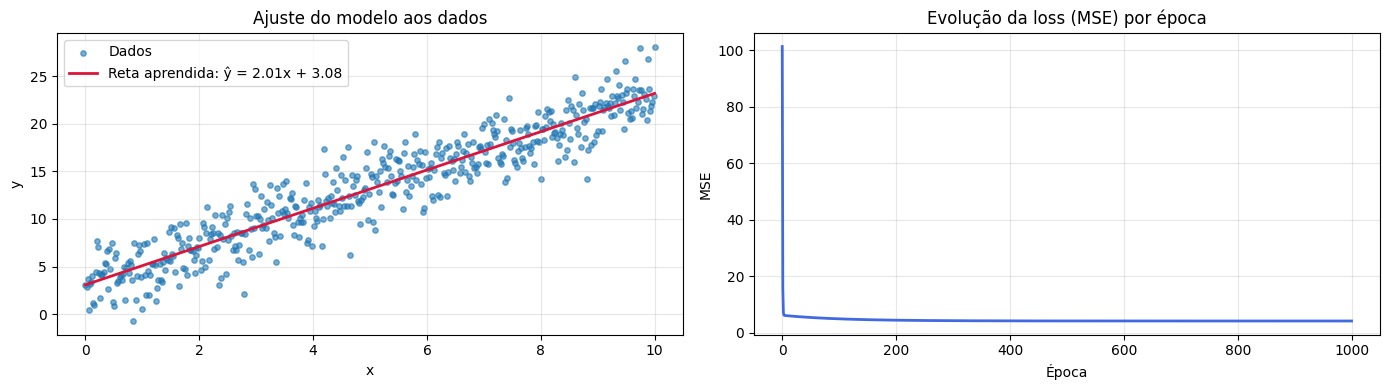

Parâmetros aprendidos: w = 2.0132  (real: 2.0) | b = 3.0753  (real: 3.0)
MSE final: 4.231258  (ruído irredutível ≈ 4.0)


In [8]:
# Plot 1: dados + reta aprendida
# Plot 2: evolução do erro (loss)

y_pred = forward_propagation(x, w, b)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Dados e reta ajustada
axes[0].scatter(x, y, s=15, alpha=0.6, label="Dados")
axes[0].plot(x, y_pred, color="crimson", linewidth=2, label=f"Reta aprendida: ŷ = {w:.2f}x + {b:.2f}")
axes[0].set_title("Ajuste do modelo aos dados")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].grid(alpha=0.3)
axes[0].legend()

# Curva de loss
axes[1].plot(history, color="royalblue", linewidth=2)
axes[1].set_title("Evolução da loss (MSE) por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("MSE")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Parâmetros aprendidos: w = {w:.4f}  (real: 2.0) | b = {b:.4f}  (real: 3.0)")
print(f"MSE final: {history[-1]:.6f}  (ruído irredutível ≈ {2**2:.1f})")

---

## Conclusão

Neste notebook construímos um **regressor linear treinado por gradiente descendente** completamente do zero, sem nenhuma biblioteca de machine learning.

**O que foi implementado:**

| Componente | Função | Equação-chave |
|---|---|---|
| Predição | `forward_propagation` | $\hat{y} = wx + b$ |
| Erro | `mse` | $\mathcal{L} = \frac{1}{N}\sum(y_i-\hat{y}_i)^2$ |
| Atualização | `backward_propagation` | $w \leftarrow w - \eta\,\partial\mathcal{L}/\partial w$ |
| Treinamento | `model_fit` | loop de `epochs` iterações |

**Conexão com redes neurais:**  
Uma rede neural é essencialmente um conjunto de regressões lineares encadeadas, com **funções de ativação não-lineares** entre as camadas. O gradiente descendente e o ciclo forward/backward aqui implementados são exatamente os mesmos usados para treinar redes profundas  a diferença é que o backward passa por múltiplas camadas via **regra da cadeia** (backpropagation).